# Import the tool 

In [3]:
# --- Core data handling ---
import pandas as pd
import numpy as np
# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning (scikit-learn) ---
from sklearn.model_selection import train_test_split          # split data into train/test
from sklearn.compose import ColumnTransformer                 # apply different prep to different columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # scale numbers / encode categories
from sklearn.pipeline import Pipeline                         # bundle preprocessing + model together
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Saving the model ---
import joblib

# Make charts look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Show all columns when we print a DataFrame
pd.set_option("display.max_columns", None)

print("Libraries imported successfully ")

Libraries imported successfully 


# Step 1 is load the dataset

In [4]:

# read_csv() loads the CSV file into a pandas DataFrame 
df = pd.read_csv("mudah-apartment-kl-selangor.csv")

# .shape gives (number_of_rows, number_of_columns)
print("Dataset shape (rows, columns):", df.shape)

# .head() shows the first 5 rows so we can see what the data looks like
df.head()

Dataset shape (rows, columns): (19991, 14)


,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swi...","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, ...","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur
2,100323128,Pangsapuri Teratak Muhibbah 2,NaN,RM 1 000 per month,Kuala Lumpur - Taman Desa,Apartment,3,NaN,2.0,650 sq.ft.,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur
3,100191767,Sentul Point Suite Apartment,2020.0,RM 1 700 per month,Kuala Lumpur - Sentul,Apartment,2,1.0,2.0,743 sq.ft.,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Cou...","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur
4,97022692,Arte Mont Kiara,NaN,RM 1 299 per month,Kuala Lumpur - Mont Kiara,Service Residence,1,1.0,1.0,494 sq.ft.,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...",Air-Cond,Kuala Lumpur


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  object 
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  object 
 4   location               19991 non-null  object 
 5   property_type          19991 non-null  object 
 6   rooms                  19985 non-null  object 
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  object 
 10  furnished              19986 non-null  object 
 11  facilities             17782 non-null  object 
 12  additional_facilities  14043 non-null  object 
 13  region                 19991 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 2.1+

Find the missing value

In [6]:
print("Missing values per column:")
df.isnull().sum().sort_values(ascending=False)

Missing values per column:


completion_year          9185
additional_facilities    5948
parking                  5702
facilities               2209
prop_name                 948
rooms                       6
bathroom                    6
furnished                   5
monthly_rent                2
ads_id                      0
location                    0
property_type               0
size                        0
region                      0
dtype: int64

In [7]:
print("Rows before:", len(df))

# Check duplicates using every column except ads_id
df = df.drop_duplicates(subset=df.columns.drop("ads_id"))

print("Rows after:", len(df))

Rows before: 19991
Rows after: 18450


In [8]:
# "RM 4 200 per month"  ->  4200
df["monthly_rent"] = (df["monthly_rent"]
                      .str.replace("RM", "")
                      .str.replace("per month", "")
                      .str.replace(" ", ""))
df["monthly_rent"] = pd.to_numeric(df["monthly_rent"], errors="coerce")

# "1842 sq.ft."  ->  1842
df["size"] = df["size"].str.replace("sq.ft.", "").str.strip()
df["size"] = pd.to_numeric(df["size"], errors="coerce")

# "3.0" -> 3.0,  "More than 10" -> NaN
df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce")

df[["monthly_rent", "size", "rooms"]].head()

,monthly_rent,size,rooms
0,4200.0,1842,5.0
1,2300.0,1170,3.0
2,1000.0,650,3.0
3,1700.0,743,2.0
4,1299.0,494,1.0


In [9]:
df["location"] = df["location"].str.split(" - ").str[1]
df["location"].value_counts().head(10)

location
Cheras            1958
Kajang             900
Shah Alam          900
Setapak            889
Cyberjaya          809
Puchong            758
Sentul             691
Seri Kembangan     682
Kepong             632
Ampang             591
Name: count, dtype: int64

In [10]:
df = df.drop(columns=["ads_id", "prop_name", "completion_year",
                      "facilities", "additional_facilities"])
df.head()

,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,region
0,4200.0,Taman Desa,Condominium,5.0,2.0,6.0,1842,Fully Furnished,Kuala Lumpur
1,2300.0,Cheras,Condominium,3.0,1.0,2.0,1170,Partially Furnished,Kuala Lumpur
2,1000.0,Taman Desa,Apartment,3.0,NaN,2.0,650,Fully Furnished,Kuala Lumpur
3,1700.0,Sentul,Apartment,2.0,1.0,2.0,743,Partially Furnished,Kuala Lumpur
4,1299.0,Mont Kiara,Service Residence,1.0,1.0,1.0,494,Not Furnished,Kuala Lumpur


In [11]:
df["parking"] = df["parking"].fillna(df["parking"].median())
df = df.dropna()

print("Missing values left:", df.isnull().sum().sum())
print("Rows now:", len(df))

Missing values left: 0
Rows now: 18440


In [12]:
# The property types we want to keep
main_types = ["Condominium", "Service Residence", "Apartment", "Flat", "Studio", "Duplex"]

# Any type NOT in the list becomes "Others"
df.loc[~df["property_type"].isin(main_types), "property_type"] = "Others"

df["property_type"].value_counts()

property_type
Condominium          7710
Service Residence    4910
Apartment            4905
Flat                  550
Studio                176
Others                115
Duplex                 74
Name: count, dtype: int64

In [13]:
print("Before:", len(df))

# Keep only sensible rents and sizes
df = df[df["monthly_rent"].between(300, 10000)]
df = df[df["size"].between(200, 5000)]

print("After:", len(df))

Before: 18440
After: 18258


In [14]:
df[["monthly_rent", "size"]].describe()


,monthly_rent,size
count,18258.000000,18258.000000
mean,1609.739073,918.645963
std,824.357980,304.255176
min,300.000000,200.000000
25%,1100.000000,750.000000
50%,1450.000000,893.000000
75%,1850.000000,1044.000000
max,10000.000000,5000.000000


In [15]:
df.to_csv("cleaned_rent_data.csv", index=False)
print("Saved cleaned_rent_data.csv")

Saved cleaned_rent_data.csv


# Exploratory Data Analysis (EDA)¶


In [16]:
df.describe()


,monthly_rent,rooms,parking,bathroom,size
count,18258.000000,18258.000000,18258.000000,18258.00000,18258.000000
mean,1609.739073,2.687479,1.295651,1.89369,918.645963
std,824.357980,0.799530,0.507385,0.54830,304.255176
min,300.000000,1.000000,1.000000,1.00000,200.000000
25%,1100.000000,2.000000,1.000000,2.00000,750.000000
50%,1450.000000,3.000000,1.000000,2.00000,893.000000
75%,1850.000000,3.000000,2.000000,2.00000,1044.000000
max,10000.000000,10.000000,10.000000,8.00000,5000.000000


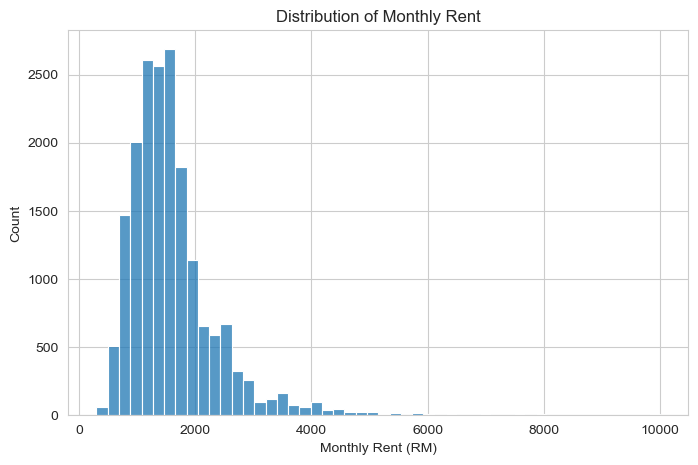

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["monthly_rent"], bins=50)
plt.title("Distribution of Monthly Rent")
plt.xlabel("Monthly Rent (RM)")
plt.show()

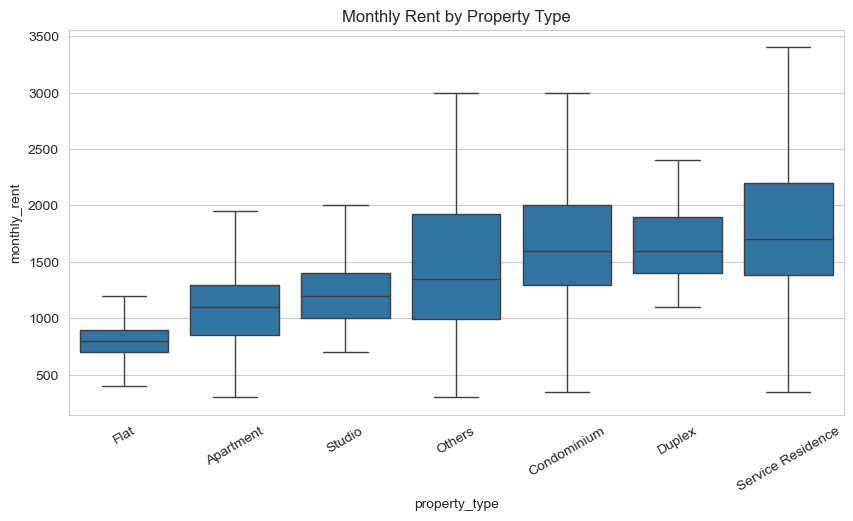

In [18]:
plt.figure(figsize=(10, 5))
order = df.groupby("property_type")["monthly_rent"].median().sort_values().index
sns.boxplot(data=df, x="property_type", y="monthly_rent", order=order, showfliers=False)
plt.title("Monthly Rent by Property Type")
plt.xticks(rotation=30)
plt.show()

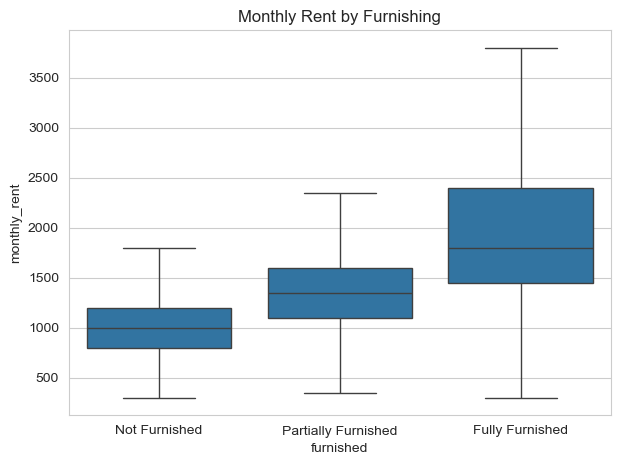

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="furnished", y="monthly_rent", showfliers=False,
            order=["Not Furnished", "Partially Furnished", "Fully Furnished"])
plt.title("Monthly Rent by Furnishing")
plt.show()


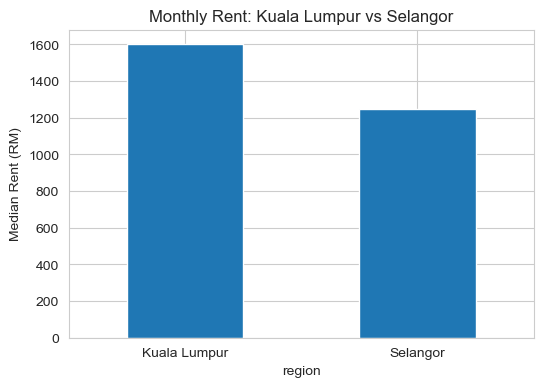

In [21]:
df.groupby("region")["monthly_rent"].median().plot(kind="bar", figsize=(6, 4))
plt.title("Monthly Rent: Kuala Lumpur vs Selangor")
plt.ylabel("Median Rent (RM)")
plt.xticks(rotation=0)
plt.show()

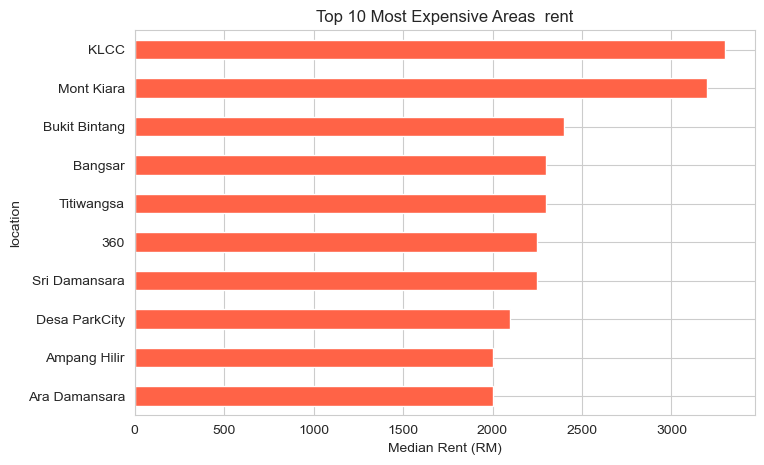

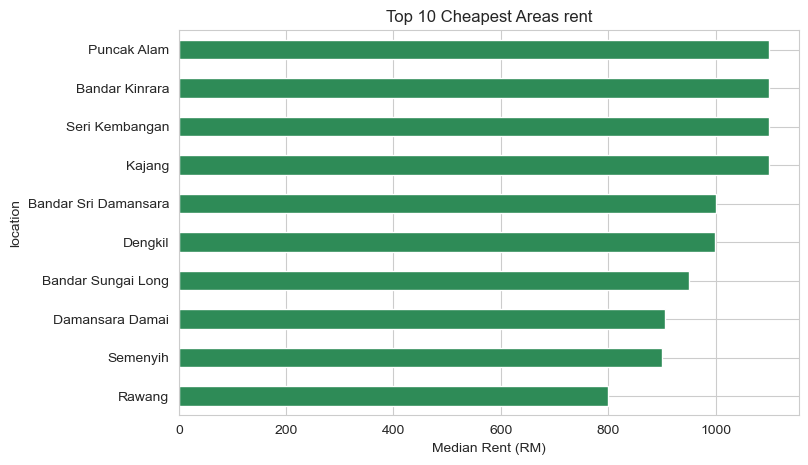

In [23]:
# Step 1: keep only areas with at least 30 listings
area_counts = df["location"].value_counts()
big_areas = area_counts[area_counts >= 30].index
df_big = df[df["location"].isin(big_areas)]

# Step 2: median rent for each area, sorted from cheapest to most expensive
area_rent = df_big.groupby("location")["monthly_rent"].median().sort_values()

# Chart 1: most expensive areas
area_rent.tail(10).plot(kind="barh", color="tomato", figsize=(8, 5))
plt.title("Top 10 Most Expensive Areas  rent")
plt.xlabel("Median Rent (RM)")
plt.show()

# Chart 2: cheapest areas
area_rent.head(10).plot(kind="barh", color="seagreen", figsize=(8, 5))
plt.title("Top 10 Cheapest Areas rent")
plt.xlabel("Median Rent (RM)")
plt.show()

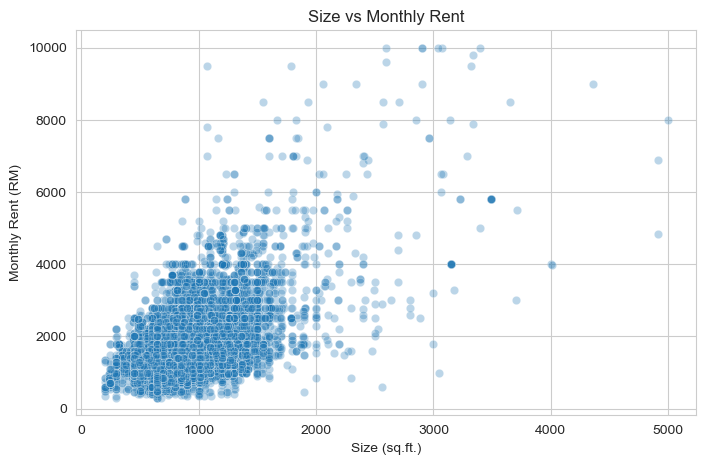

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="size", y="monthly_rent", alpha=0.3)
plt.title("Size vs Monthly Rent")
plt.xlabel("Size (sq.ft.)")
plt.ylabel("Monthly Rent (RM)")
plt.show()

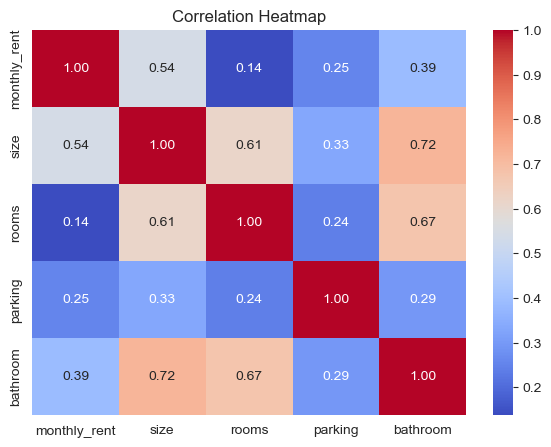

In [25]:
plt.figure(figsize=(7, 5))
num_cols = ["monthly_rent", "size", "rooms", "parking", "bathroom"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()